<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-09-02 16:36:13--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  3.95MB/s    in 44s     

2026-09-02 16:36:57 (4.58 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 153.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 178.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 156.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 170.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [4]:
!pip install seaborn

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

#### Connect to the SQLite database


In [6]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [13]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


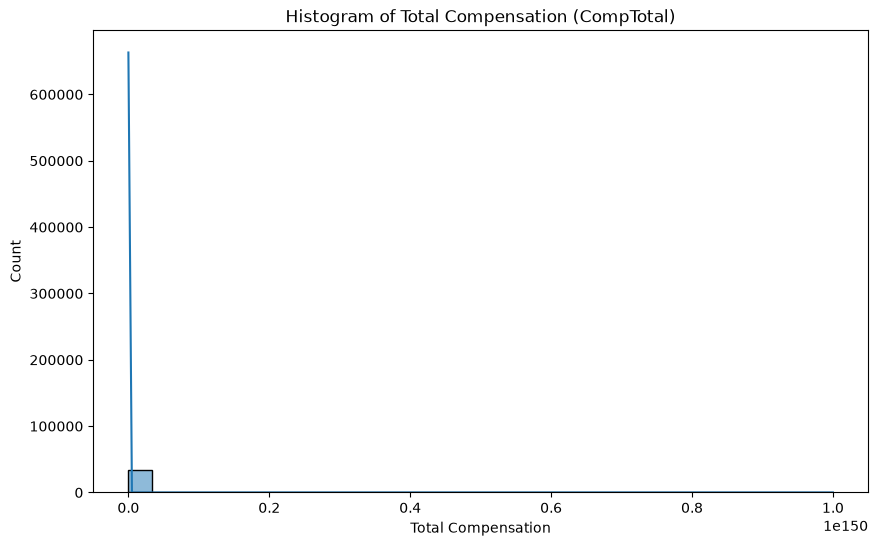

In [9]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Query CompTotal data directly from your SQLite database
QUERY = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_comp['CompTotal'], bins=30, kde=True)

plt.title('Histogram of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.show() 

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


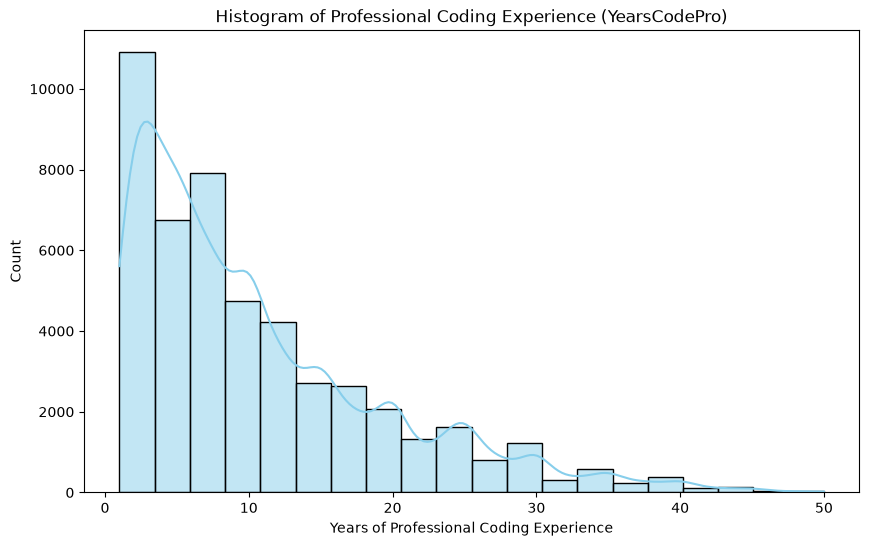

In [11]:
## Write your code here
# Query YearsCodePro data from the SQLite database
QUERY = """
SELECT YearsCodePro 
FROM main 
WHERE YearsCodePro IS NOT NULL
"""
df_experience = pd.read_sql_query(QUERY, conn)

# Convert column to numeric to handle any string entries
df_experience['YearsCodePro'] = pd.to_numeric(df_experience['YearsCodePro'], errors='coerce')

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_experience['YearsCodePro'].dropna(), bins=20, kde=True, color='skyblue')

plt.title('Histogram of Professional Coding Experience (YearsCodePro)')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Count')
plt.show() 

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


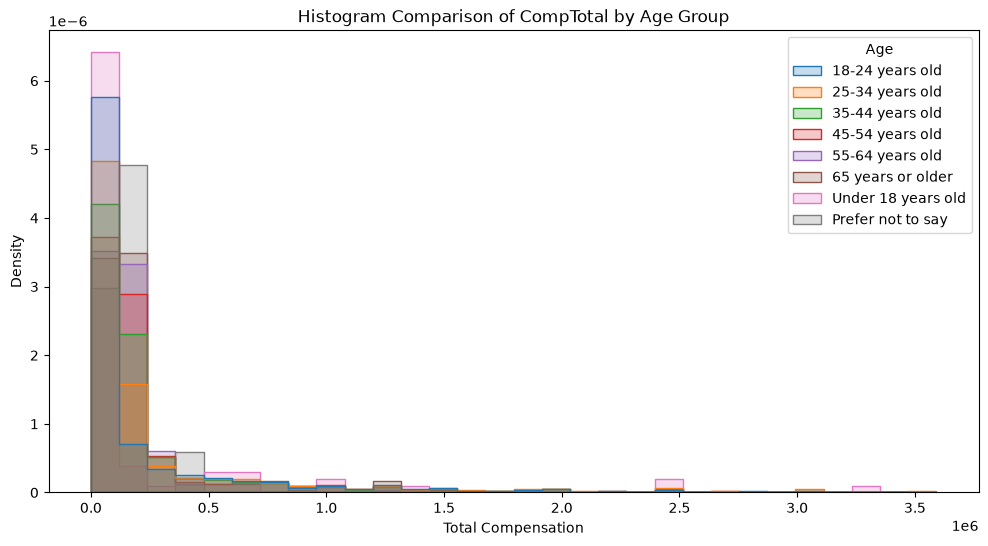

In [10]:
## Write your code here
# Query CompTotal and Age data from SQLite database
QUERY = """
SELECT CompTotal, Age 
FROM main 
WHERE CompTotal IS NOT NULL AND Age IS NOT NULL
"""
df_comp_age = pd.read_sql_query(QUERY, conn)

# Filter out extreme compensation outliers for clearer visualization
df_filtered = df_comp_age[df_comp_age['CompTotal'] < df_comp_age['CompTotal'].quantile(0.95)]

# Plot overlapping/grouped histogram comparison
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_filtered, 
    x='CompTotal', 
    hue='Age', 
    element='step', 
    stat='density', 
    common_norm=False, 
    bins=30
)

plt.title('Histogram Comparison of CompTotal by Age Group')
plt.xlabel('Total Compensation')
plt.ylabel('Density')
plt.show() 

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


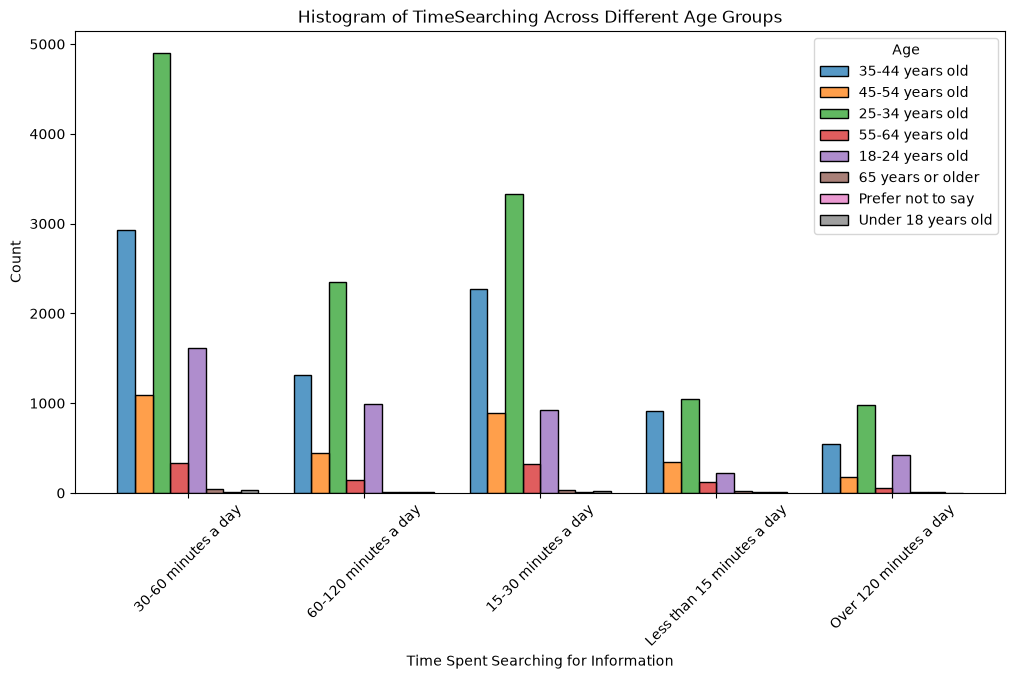

In [12]:
## Write your code here
# Query TimeSearching and Age data from SQLite database
QUERY = """
SELECT TimeSearching, Age 
FROM main 
WHERE TimeSearching IS NOT NULL AND Age IS NOT NULL
"""
df_search_age = pd.read_sql_query(QUERY, conn)

# Plot histogram of TimeSearching segmented by Age group
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_search_age, 
    x='TimeSearching', 
    hue='Age', 
    multiple='dodge', 
    shrink=0.8
)

plt.title('Histogram of TimeSearching Across Different Age Groups')
plt.xlabel('Time Spent Searching for Information')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show() 

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


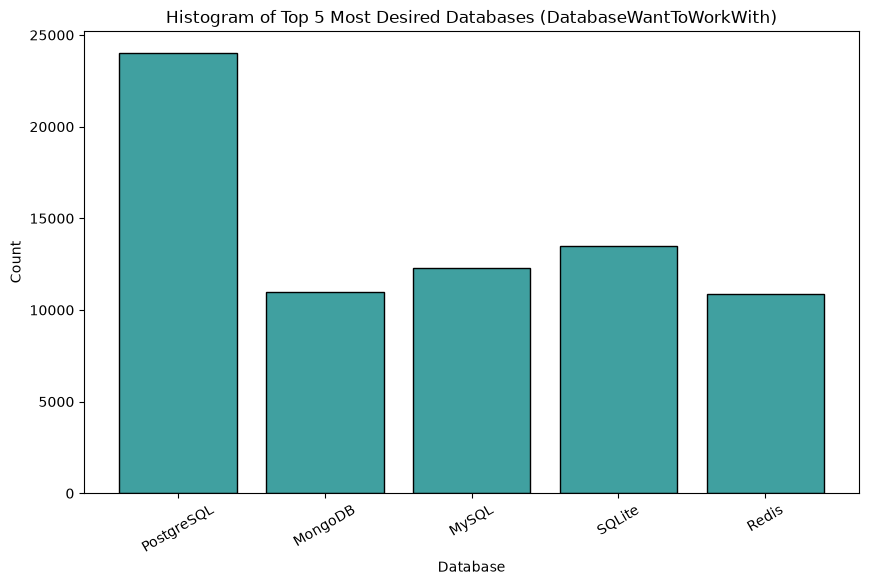

In [14]:
# Query DatabaseWantToWorkWith data from SQLite database
QUERY = """
SELECT DatabaseWantToWorkWith 
FROM main 
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
df_db = pd.read_sql_query(QUERY, conn)

# Split semi-colon separated databases, count frequencies, and get top 5
top5_db = (
    df_db['DatabaseWantToWorkWith']
    .str.split(';')
    .explode()
    .value_counts()
    .head(5)
    .reset_index()
)
top5_db.columns = ['Database', 'Count']

# Filter dataset to include only top 5 databases
df_top5 = df_db.assign(Database=df_db['DatabaseWantToWorkWith'].str.split(';')).explode('Database')
df_top5 = df_top5[df_top5['Database'].isin(top5_db['Database'])]

# Plot histogram of the top 5 most desired databases
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_top5, 
    x='Database', 
    discrete=True, 
    shrink=0.8, 
    color='teal'
)

plt.title('Histogram of Top 5 Most Desired Databases (DatabaseWantToWorkWith)')
plt.xlabel('Database')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


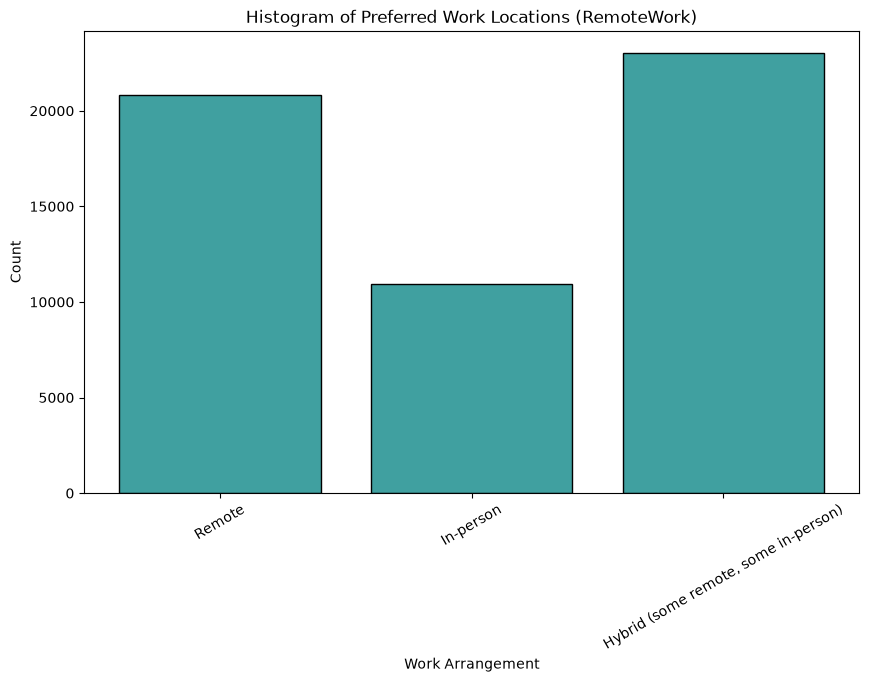

In [15]:
## Write your code here
# Query RemoteWork data from the SQLite database
QUERY = """
SELECT RemoteWork 
FROM main 
WHERE RemoteWork IS NOT NULL
"""
df_remote = pd.read_sql_query(QUERY, conn)

# Plot the distribution of preferred work locations
plt.figure(figsize=(10, 6))
sns.histplot(data=df_remote, x='RemoteWork', shrink=0.8, color='teal')

plt.title('Histogram of Preferred Work Locations (RemoteWork)')
plt.xlabel('Work Arrangement')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show() 

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


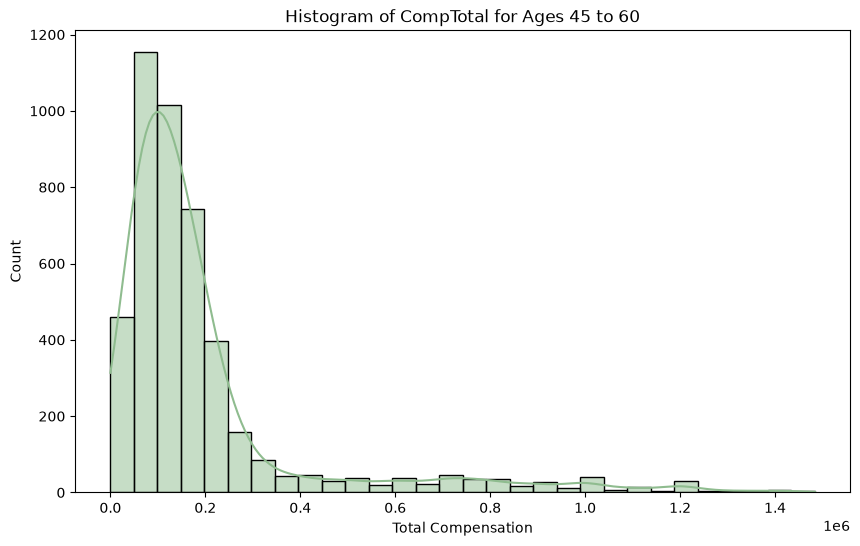

In [16]:
## Write your code here
# Query CompTotal for respondents in the age group '45-54 years' or '55-64 years' (or numeric age 45 to 60)
QUERY = """
SELECT CompTotal 
FROM main 
WHERE (Age BETWEEN '45' AND '60' OR Age LIKE '%45%' OR Age LIKE '%55%') 
  AND CompTotal IS NOT NULL
"""
df_mid_career = pd.read_sql_query(QUERY, conn)

# Alternatively, if Age is already filtered or converted:
# df_mid_career = df_comp_age[(df_comp_age['Age'] >= 45) & (df_comp_age['Age'] <= 60)]

# Filter out extreme compensation outliers for better visual clarity
df_filtered = df_mid_career[df_mid_career['CompTotal'] < df_mid_career['CompTotal'].quantile(0.95)]

# Plot histogram of CompTotal for respondents aged 45 to 60
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['CompTotal'], bins=30, kde=True, color='darkseagreen')

plt.title('Histogram of CompTotal for Ages 45 to 60')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


/tmp/ipykernel_373/13032761.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Job Satisfaction')

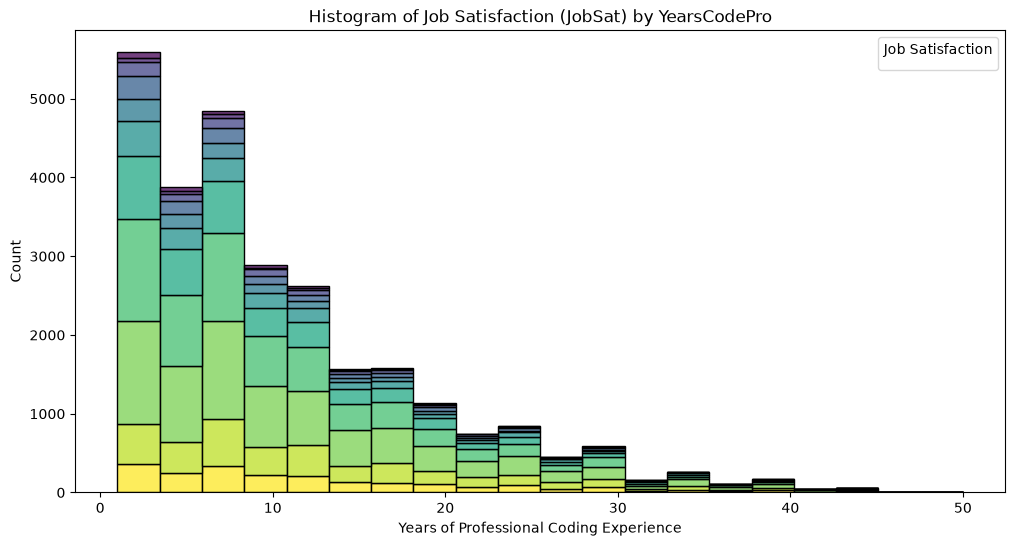

In [17]:
## Write your code here
# Query JobSat and YearsCodePro data from SQLite database
QUERY = """
SELECT JobSat, YearsCodePro 
FROM main 
WHERE JobSat IS NOT NULL AND YearsCodePro IS NOT NULL
"""
df_jobsat_exp = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric
df_jobsat_exp['YearsCodePro'] = pd.to_numeric(df_jobsat_exp['YearsCodePro'], errors='coerce')

# Drop rows with NaN values after conversion
df_jobsat_exp = df_jobsat_exp.dropna(subset=['YearsCodePro'])

# Plot histogram of JobSat segmented across YearsCodePro
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_jobsat_exp, 
    x='YearsCodePro', 
    hue='JobSat', 
    multiple='stack', 
    bins=20, 
    palette='viridis'
)

plt.title('Histogram of Job Satisfaction (JobSat) by YearsCodePro')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Count')
plt.legend(title='Job Satisfaction')
plt.show() 

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [18]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
